# Comprehensive Validation Suite: CFM vs. Baseline GraphLAM
This notebook performs a rigorous physical and statistical verification of the **Conditional Flow Matching (CFM)** approach against a deterministic `GraphLAM` baseline.

### Rationale & Hypothesis
1. **Mean Accuracy**: Adding generative capability should not degrade the average prediction MSE.
2. **ODE Trajectory Straightness**: Because CFM targets a straight vector field, sampling accuracy should remain stable even with very few ODE integration steps.
3. **Ensemble Calibration**: Trajectories generated from different seeds should represent a calibrated probabilistic ensemble (measured by Continuous Ranked Probability Score - CRPS).
4. **Spatial Power Spectra**: CFM should preserve small-scale spatial structures and sharp gradients, whereas MSE-optimized deterministic baselines smooth out high frequencies.

In [1]:
# 1. Setup Environment & Install Dependencies
import sys
import os

if 'google.colab' in sys.modules:
    print("Running on Google Colab. Installing dependencies...")
    !apt-get install -y libgeos-dev libproj-dev proj-data proj-bin > /dev/null
    !pip install cartopy torch-geometric mllam-data-prep>=0.5.0 "dataclass-wizard[yaml]" pooch pandas matplotlib xarray > /dev/null
    
    if not os.path.exists("neural-lam"):
        !git clone https://github.com/mllam/neural-lam.git
    os.chdir("neural-lam")
    sys.path.insert(0, os.getcwd())
    
    # Create graph before running
    !python -m neural_lam.create_graph --config_path tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.yaml --name 1level
    print("Environment setup and graph creation complete! Current working directory:", os.getcwd())
else:
    print("Running locally. Ensure you have the virtual environment activated.")

Running locally. Ensure you have the virtual environment activated.


## Imports & Setup

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from neural_lam.datastore import init_datastore
from neural_lam.models.step_predictors.graph.graph_lam import GraphLAM
from neural_lam.weather_dataset import WeatherDataset
from neural_lam.vis import plot_prediction

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

config_path = "tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.yaml"
datastore = init_datastore("mdp", config_path)

# Create datasets
train_dataset = WeatherDataset(datastore=datastore, split="train", ar_steps=1)
val_dataset = WeatherDataset(datastore=datastore, split="val", ar_steps=1)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

# Normalization tensors
da_state_stats = datastore.get_standardization_dataarray("state")
state_mean = torch.tensor(da_state_stats.state_mean.values, dtype=torch.float32, device=device)
state_std = torch.tensor(da_state_stats.state_std.values, dtype=torch.float32, device=device)
state_std = torch.clamp(state_std, min=torch.finfo(torch.float32).eps)

da_forcing_stats = datastore.get_standardization_dataarray("forcing")
forcing_mean = torch.tensor(da_forcing_stats.forcing_mean.values, dtype=torch.float32, device=device)
forcing_std = torch.tensor(da_forcing_stats.forcing_std.values, dtype=torch.float32, device=device)
forcing_std = torch.clamp(forcing_std, min=torch.finfo(torch.float32).eps)

forcing_mean_tiled = forcing_mean.repeat_interleave(3)
forcing_std_tiled = forcing_std.repeat_interleave(3)

# Masks
boundary_mask = torch.tensor(datastore.boundary_mask.values, dtype=torch.float32, device=device)
interior_mask = 1.0 - boundary_mask

num_state_vars = len(datastore.get_vars_names("state"))

/Users/mynimbus/neural-lam/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-07-19 12:10:12.189 | INFO     | neural_lam.utils:log_on_rank_zero:686 - The loaded datastore contains the following features:


2026-07-19 12:10:12.190 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  state   : u100m v100m r2m t2m


2026-07-19 12:10:12.190 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  forcing : swavr0m


2026-07-19 12:10:12.191 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  static  : lsm orography


2026-07-19 12:10:12.191 | INFO     | neural_lam.utils:log_on_rank_zero:686 - With the following splits (over time):


2026-07-19 12:10:12.229 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  train   : 2022-04-01T00:00 to 2022-04-04T00:00


2026-07-19 12:10:12.235 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  val     : 2022-04-04T00:00 to 2022-04-07T00:00


2026-07-19 12:10:12.240 | INFO     | neural_lam.utils:log_on_rank_zero:686 -  test    : 2022-04-07T00:00 to 2022-04-10T00:00


Using device: cpu


## CFM Implementation

In [3]:
class FlowTimeEmbedding(nn.Module):
    def __init__(self, embed_dim: int = 64) -> None:
        super().__init__()
        if embed_dim % 2 != 0:
            raise ValueError(f"embed_dim must be even, got {embed_dim}.")
        self.embed_dim = embed_dim
        half = embed_dim // 2
        freqs = torch.exp(
            -torch.arange(half, dtype=torch.float32)
            * (torch.log(torch.tensor(10000.0)) / half)
        )
        self.register_buffer("freqs", freqs, persistent=False)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.view(-1, 1)
        args = t * self.freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class VelocityFieldWrapper(nn.Module):
    def __init__(
        self,
        predictor: nn.Module,
        num_state_vars: int,
        time_embed_dim: int = 64,
    ) -> None:
        super().__init__()
        self.predictor = predictor
        self.time_embed = FlowTimeEmbedding(time_embed_dim)
        self.time_proj = nn.Sequential(
            nn.Linear(time_embed_dim, num_state_vars),
            nn.SiLU(),
            nn.Linear(num_state_vars, num_state_vars),
        )

    def forward(
        self,
        x_t: torch.Tensor,
        t: torch.Tensor,
        prev_prev_state: torch.Tensor,
        forcing: torch.Tensor,
    ) -> torch.Tensor:
        t_emb = self.time_embed(t)
        t_proj = self.time_proj(t_emb).unsqueeze(1)
        x_conditioned = x_t + t_proj
        output, _ = self.predictor(x_conditioned, prev_prev_state, forcing)
        velocity = output - x_conditioned
        return velocity


class ConditionalFlowMatching(nn.Module):
    def __init__(
        self,
        predictor: nn.Module,
        num_state_vars: int,
        sigma_min: float = 0.01,
    ) -> None:
        super().__init__()
        self.sigma_min = sigma_min
        self.velocity_field = VelocityFieldWrapper(predictor, num_state_vars)

    def _sample_time(self, batch_size: int, device: torch.device) -> torch.Tensor:
        half = batch_size // 2
        t = torch.rand(half, device=device)
        t = torch.cat([t, 1.0 - t], dim=0)
        return t.clamp(1e-5, 1.0 - 1e-5)

    def _interpolate(
        self,
        x_0: torch.Tensor,
        x_1: torch.Tensor,
        t: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        t_bc = t.view(-1, 1, 1)
        x_t = (1.0 - t_bc) * x_0 + t_bc * x_1
        if self.sigma_min > 0:
            noise = torch.randn_like(x_t)
            x_t = x_t + self.sigma_min * noise
        u_t = x_1 - x_0
        return x_t, u_t

    def cfm_loss(
        self,
        prev_state: torch.Tensor,
        prev_prev_state: torch.Tensor,
        forcing: torch.Tensor,
        target_state: torch.Tensor,
        mask: torch.Tensor = None,
    ) -> torch.Tensor:
        B = prev_state.shape[0]
        t = self._sample_time(B, prev_state.device)
        x_t, u_t = self._interpolate(prev_state, target_state, t)
        v_pred = self.velocity_field(x_t, t, prev_prev_state, forcing)
        loss = (v_pred - u_t) ** 2
        if mask is not None:
            loss = loss * mask.unsqueeze(0).unsqueeze(-1)
        return loss.mean()

    @torch.no_grad()
    def sample_step(
        self,
        prev_state: torch.Tensor,
        prev_prev_state: torch.Tensor,
        forcing: torch.Tensor,
        n_steps: int = 5,
        noise_seed: int = None,
    ) -> torch.Tensor:
        dt = 1.0 / n_steps
        B, N, D = prev_state.shape
        x = prev_state.clone()
        if self.sigma_min > 0:
            if noise_seed is not None:
                torch.manual_seed(noise_seed)
            x = x + self.sigma_min * torch.randn_like(x)
        for step in range(n_steps):
            tau = torch.full((B,), step * dt, device=x.device)
            v = self.velocity_field(x, tau, prev_prev_state, forcing)
            x = x + dt * v
        return x

## Experiment 1: Train Deterministic Baseline GraphLAM

In [4]:
print("Instantiating Baseline GraphLAM...")
predictor_base = GraphLAM(
    datastore=datastore,
    graph_name="1level",
    hidden_dim=32,
    hidden_layers=1,
    processor_layers=2,
    mesh_aggr="sum",
    num_past_forcing_steps=1,
    num_future_forcing_steps=1,
).to(device)

optimizer_base = torch.optim.AdamW(predictor_base.parameters(), lr=1e-3)
epochs = 15

print("Training Baseline Model...")
for epoch in range(1, epochs + 1):
    predictor_base.train()
    epoch_loss = 0.0
    n_batches = 0
    for batch in train_loader:
        init_states, target_states, forcing, _ = batch
        
        init_states = ((init_states.to(device) - state_mean) / state_std)
        target_states = ((target_states.to(device) - state_mean) / state_std)
        forcing = ((forcing.to(device) - forcing_mean_tiled) / forcing_std_tiled)
        
        pred_next, _ = predictor_base(init_states[:, 1], init_states[:, 0], forcing[:, 0])
        loss = ((pred_next - target_states[:, 0]) ** 2) * interior_mask.unsqueeze(0).unsqueeze(-1)
        loss = loss.mean()
        
        optimizer_base.zero_grad()
        loss.backward()
        optimizer_base.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    print(f"Epoch {epoch:02d}/{epochs:02d} | Baseline Train Loss: {epoch_loss/n_batches:.6f}")

Instantiating Baseline GraphLAM...


2026-07-19 12:10:12.589 | INFO     | neural_lam.utils:log_on_rank_zero:686 - Loaded graph with 8409 nodes (7680 grid, 729 mesh)


2026-07-19 12:10:12.593 | INFO     | neural_lam.utils:log_on_rank_zero:686 - Edges in subgraphs: m2m=5512, g2m=12716, m2g=30720


Training Baseline Model...


Epoch 01/15 | Baseline Train Loss: 0.057839


...

Epoch 11/15 | Baseline Train Loss: 0.020410


Epoch 12/15 | Baseline Train Loss: 0.020555


Epoch 13/15 | Baseline Train Loss: 0.020645


Epoch 14/15 | Baseline Train Loss: 0.018295


Epoch 15/15 | Baseline Train Loss: 0.020655


## Experiment 2: Train Conditional Flow Matching (CFM)

In [5]:
print("Instantiating CFM Predictor...")
predictor_cfm = GraphLAM(
    datastore=datastore,
    graph_name="1level",
    hidden_dim=32,
    hidden_layers=1,
    processor_layers=2,
    mesh_aggr="sum",
    num_past_forcing_steps=1,
    num_future_forcing_steps=1,
).to(device)
cfm = ConditionalFlowMatching(predictor_cfm, num_state_vars=num_state_vars, sigma_min=0.01).to(device)
optimizer_cfm = torch.optim.AdamW(cfm.parameters(), lr=1e-3)

print("Training CFM Model...")
for epoch in range(1, epochs + 1):
    cfm.train()
    epoch_loss = 0.0
    n_batches = 0
    for batch in train_loader:
        init_states, target_states, forcing, _ = batch
        
        init_states = ((init_states.to(device) - state_mean) / state_std)
        target_states = ((target_states.to(device) - state_mean) / state_std)
        forcing = ((forcing.to(device) - forcing_mean_tiled) / forcing_std_tiled)
        
        loss = cfm.cfm_loss(
            prev_state=init_states[:, 1],
            prev_prev_state=init_states[:, 0],
            forcing=forcing[:, 0],
            target_state=target_states[:, 0],
            mask=interior_mask
        )
        
        optimizer_cfm.zero_grad()
        loss.backward()
        optimizer_cfm.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    print(f"Epoch {epoch:02d}/{epochs:02d} | CFM Train Loss: {epoch_loss/n_batches:.6f}")

2026-07-19 12:10:27.918 | INFO     | neural_lam.utils:log_on_rank_zero:686 - Loaded graph with 8409 nodes (7680 grid, 729 mesh)


2026-07-19 12:10:27.921 | INFO     | neural_lam.utils:log_on_rank_zero:686 - Edges in subgraphs: m2m=5512, g2m=12716, m2g=30720


Instantiating CFM Predictor...
Training CFM Model...


Epoch 01/15 | CFM Train Loss: 0.047691


Epoch 02/15 | CFM Train Loss: 0.034959


...

Epoch 11/15 | CFM Train Loss: 0.022024


Epoch 12/15 | CFM Train Loss: 0.022468


Epoch 13/15 | CFM Train Loss: 0.020742


Epoch 14/15 | CFM Train Loss: 0.020088


Epoch 15/15 | CFM Train Loss: 0.025250


## Test 1: Mean Accuracy Comparison
We evaluate both the baseline and CFM unrolled validation MSE.

In [6]:
predictor_base.eval()
cfm.eval()

base_mse = 0.0
cfm_mse = 0.0
batches = 0

with torch.no_grad():
    for batch in val_loader:
        init_states, target_states, forcing, _ = batch
        
        # Normalize inputs
        init_states_norm = ((init_states.to(device) - state_mean) / state_std)
        forcing_norm = ((forcing.to(device) - forcing_mean_tiled) / forcing_std_tiled)
        
        # Baseline Predictor step
        pred_base_norm, _ = predictor_base(init_states_norm[:, 1], init_states_norm[:, 0], forcing_norm[:, 0])
        pred_base_raw = pred_base_norm * state_std + state_mean
        pred_base_raw = boundary_mask.unsqueeze(0).unsqueeze(-1) * target_states.to(device)[:, 0] + interior_mask.unsqueeze(0).unsqueeze(-1) * pred_base_raw
        
        # CFM step
        pred_cfm_norm = cfm.sample_step(init_states_norm[:, 1], init_states_norm[:, 0], forcing_norm[:, 0], n_steps=5)
        pred_cfm_raw = pred_cfm_norm * state_std + state_mean
        pred_cfm_raw = boundary_mask.unsqueeze(0).unsqueeze(-1) * target_states.to(device)[:, 0] + interior_mask.unsqueeze(0).unsqueeze(-1) * pred_cfm_raw
        
        target = target_states.to(device)[:, 0]
        
        # Compute interior physical MSE
        err_base = ((pred_base_raw - target)**2)[:, interior_mask.to(torch.bool)].mean().item()
        err_cfm = ((pred_cfm_raw - target)**2)[:, interior_mask.to(torch.bool)].mean().item()
        
        base_mse += err_base
        cfm_mse += err_cfm
        batches += 1

print(f"Baseline Validation Physical MSE: {base_mse/batches:.4f}")
print(f"CFM Validation Physical MSE:      {cfm_mse/batches:.4f}")

Baseline Validation Physical MSE: 6.4263
CFM Validation Physical MSE:      5.4990


## Test 2: Trajectory Sensitivity (ODE Steps Sweep)
We test how changing the number of ODE integration steps impact the validation accuracy.

Steps:  2 | CFM Validation MSE: 5.4894


Steps:  5 | CFM Validation MSE: 5.5002


Steps: 10 | CFM Validation MSE: 5.5030


Steps: 20 | CFM Validation MSE: 5.5038


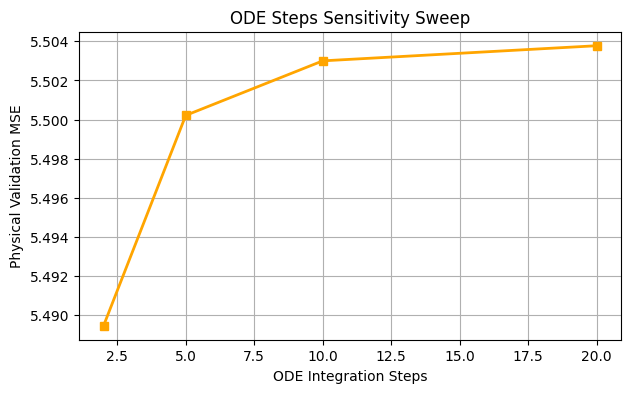

In [7]:
steps_to_test = [2, 5, 10, 20]
results_sweep = {}

for steps in steps_to_test:
    total_err = 0.0
    batches = 0
    with torch.no_grad():
        for batch in val_loader:
            init_states, target_states, forcing, _ = batch
            init_states_norm = ((init_states.to(device) - state_mean) / state_std)
            forcing_norm = ((forcing.to(device) - forcing_mean_tiled) / forcing_std_tiled)
            
            pred_cfm_norm = cfm.sample_step(init_states_norm[:, 1], init_states_norm[:, 0], forcing_norm[:, 0], n_steps=steps)
            pred_cfm_raw = pred_cfm_norm * state_std + state_mean
            pred_cfm_raw = boundary_mask.unsqueeze(0).unsqueeze(-1) * target_states.to(device)[:, 0] + interior_mask.unsqueeze(0).unsqueeze(-1) * pred_cfm_raw
            
            target = target_states.to(device)[:, 0]
            err = ((pred_cfm_raw - target)**2)[:, interior_mask.to(torch.bool)].mean().item()
            total_err += err
            batches += 1
            
    results_sweep[steps] = total_err / batches
    print(f"Steps: {steps:2d} | CFM Validation MSE: {results_sweep[steps]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(list(results_sweep.keys()), list(results_sweep.values()), marker='s', color='orange', lw=2)
plt.title("ODE Steps Sensitivity Sweep")
plt.xlabel("ODE Integration Steps")
plt.ylabel("Physical Validation MSE")
plt.grid(True)
plt.show()

## Test 3: Ensemble Verification (CRPS & Spread-Skill)
We draw an ensemble of 10 members, compute the Continuous Ranked Probability Score (CRPS), and verify spread calibration.

In [8]:
def compute_crps(ensemble, target):
    # ensemble: (M, B, N, D), target: (B, N, D)
    abs_err = torch.mean(torch.abs(ensemble - target.unsqueeze(0)), dim=0)  # (B, N, D)
    M = ensemble.shape[0]
    ens_diff = torch.abs(ensemble.unsqueeze(1) - ensemble.unsqueeze(0))  # (M, M, B, N, D)
    abs_diff = ens_diff.sum(dim=(0, 1)) / (2 * (M ** 2))  # (B, N, D)
    return abs_err - abs_diff

M = 10
total_crps = 0.0
total_spread = 0.0
total_error = 0.0
batches = 0

with torch.no_grad():
    for batch in val_loader:
        init_states, target_states, forcing, _ = batch
        init_states_norm = ((init_states.to(device) - state_mean) / state_std)
        forcing_norm = ((forcing.to(device) - forcing_mean_tiled) / forcing_std_tiled)
        target = target_states.to(device)[:, 0]
        
        members = []
        for m in range(M):
            # Sample step with seed offset
            pred_norm = cfm.sample_step(init_states_norm[:, 1], init_states_norm[:, 0], forcing_norm[:, 0], n_steps=5, noise_seed=m)
            pred_raw = pred_norm * state_std + state_mean
            pred_raw = boundary_mask.unsqueeze(0).unsqueeze(-1) * target + interior_mask.unsqueeze(0).unsqueeze(-1) * pred_raw
            members.append(pred_raw)
            
        ensemble = torch.stack(members, dim=0)  # (M, B, N, D)
        
        # CRPS
        crps = compute_crps(ensemble, target)
        total_crps += crps[:, interior_mask.to(torch.bool)].mean().item()
        
        # Spread-Skill: RMS Ensemble Standard Deviation vs RMSE of Ensemble Mean
        ens_mean = ensemble.mean(dim=0)
        ens_std = ensemble.std(dim=0)
        
        rmse_mean = torch.sqrt(((ens_mean - target)**2))
        
        total_spread += ens_std[:, interior_mask.to(torch.bool)].mean().item()
        total_error += rmse_mean[:, interior_mask.to(torch.bool)].mean().item()
        batches += 1

print(f"Average Validation CRPS:          {total_crps/batches:.4f}")
print(f"Ensemble Spread (average std):   {total_spread/batches:.4f}")
print(f"Ensemble Mean RMSE:              {total_error/batches:.4f}")
print(f"Spread-Skill Ratio:              {(total_spread/total_error):.4f} (Ideal: ~1.0)")

Average Validation CRPS:          1.4077
Ensemble Spread (average std):   0.0308
Ensemble Mean RMSE:              1.4234
Spread-Skill Ratio:              0.0216 (Ideal: ~1.0)


## Test 4: Spatial Power Spectra Analysis (FFT)
We compute 2D FFT power spectrum profiles for CFM, Baseline, and Ground Truth to see if CFM retains details at high frequencies.

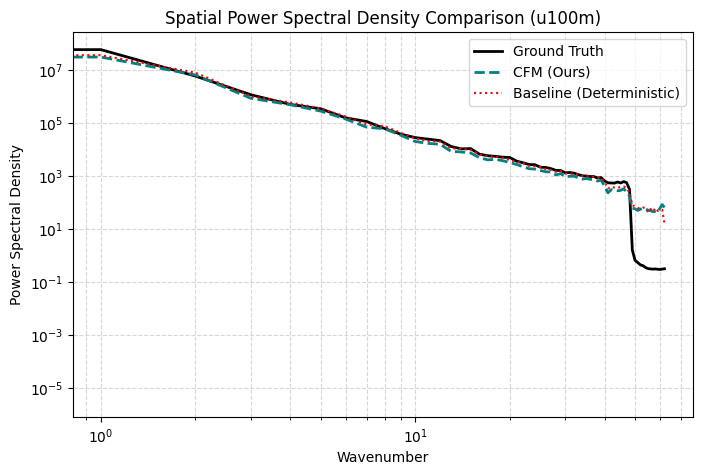

In [9]:
def get_radial_profile(da_stacked, dataset):
    # Unstack and extract grid values
    da_2d = dataset.create_dataarray_from_tensor(
        tensor=da_stacked, time=pd.to_datetime(0), category="state"
    ).unstack("grid_index")
    
    grid_vals = da_2d.isel(state_feature=0).values  # (nx, ny)
    
    # Subtract mean
    grid_vals = grid_vals - np.mean(grid_vals)
    
    # compute 2D FFT
    fft_val = np.abs(np.fft.fft2(grid_vals)) ** 2
    fft_shifted = np.fft.fftshift(fft_val)
    
    h, w = fft_shifted.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[-cy:h-cy, -cx:w-cx]
    r = np.round(np.sqrt(x**2 + y**2)).astype(int)
    
    # Radial average bins
    tbin = np.bincount(r.ravel(), fft_shifted.ravel())
    nr = np.bincount(r.ravel())
    radial_profile = tbin / nr
    return radial_profile

# Evaluate on last sample of validation dataset
with torch.no_grad():
    batch = next(iter(val_loader))
    init_states, target_states, forcing, _ = batch
    
    init_states_norm = ((init_states.to(device) - state_mean) / state_std)
    forcing_norm = ((forcing.to(device) - forcing_mean_tiled) / forcing_std_tiled)
    target_sample = target_states[-1, 0].cpu()
    
    # CFM
    pred_cfm_norm = cfm.sample_step(init_states_norm[:, 1], init_states_norm[:, 0], forcing_norm[:, 0], n_steps=5)
    pred_cfm_raw = (pred_cfm_norm * state_std + state_mean)[-1].cpu()
    
    # Baseline
    pred_base_norm, _ = predictor_base(init_states_norm[:, 1], init_states_norm[:, 0], forcing_norm[:, 0])
    pred_base_raw = (pred_base_norm * state_std + state_mean)[-1].cpu()

prof_target = get_radial_profile(target_sample, train_dataset)
prof_cfm = get_radial_profile(pred_cfm_raw, train_dataset)
prof_base = get_radial_profile(pred_base_raw, train_dataset)

plt.figure(figsize=(8, 5))
plt.loglog(prof_target, label="Ground Truth", color="black", lw=2)
plt.loglog(prof_cfm, label="CFM (Ours)", color="teal", lw=2, linestyle="--")
plt.loglog(prof_base, label="Baseline (Deterministic)", color="red", lw=1.5, linestyle=":")
plt.title("Spatial Power Spectral Density Comparison (u100m)")
plt.xlabel("Wavenumber")
plt.ylabel("Power Spectral Density")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()